In [1]:
import os
import numpy as np
import pandas as pd
import string
from datetime import timedelta
from tqdm.auto import tqdm
from typing import Any, Dict
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from copy import deepcopy
import pickle

/home/d.kornilov/work/Revealing-interconnections-between-diseases/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
N_CORES_TO_USE = 64
DATADIR = './'
SAVE_DIR = "./"
FILE_NAME = "trajectories.csv"
TARGET_CANCER = "C61"
PREDICTION_HORIZON = 3 #years
PREDICTION_HORIZON = 12*PREDICTION_HORIZON #months

In [4]:
df = pd.read_csv(DATADIR+FILE_NAME)
df['admittime'] = pd.to_datetime(df['admittime'], format='%Y-%m-%d %H:%M:%S')
df['dischtime'] = pd.to_datetime(df['dischtime'], format='%Y-%m-%d %H:%M:%S')
df["dod"] = pd.to_datetime(df['dod'], format='%Y-%m-%d')
df["birth_year"] = pd.to_datetime(df['birth_year'], format='%Y')

In [5]:
df.head()

,subject_id,hadm_id,seq_num,icd10_code,icd10_category,admittime,dischtime,deathtime,gender,birth_year,dod
0,10000032,22595853,1,K766,K76,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
1,10000032,22595853,2,R188,R18,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
2,10000032,22595853,3,K740,K74,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
3,10000032,22595853,4,B1920,B19,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
4,10000032,22595853,5,J449,J44,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09


In [5]:
df.dtypes

subject_id                 int64
hadm_id                    int64
seq_num                    int64
icd10_code                object
icd10_category            object
admittime         datetime64[ns]
dischtime         datetime64[ns]
deathtime                 object
gender                    object
birth_year        datetime64[ns]
dod               datetime64[ns]
dtype: object

In [6]:
df.shape

(5938215, 11)

## Patients selection (uses prediction horizon)

In [7]:
ALL_VALUES = df['icd10_category'].unique()

In [8]:
# MKB codes
def is_mkb(v):
    return len(v) >= 3 and (
        v[0] in string.ascii_uppercase or (ord(v[0])>=ord('А') and ord(v[0])<=ord('Я'))
    ) and v[1].isdigit() and v[2].isdigit()\
    and "-" not in v #ICD blocks

def is_cancer_mkb(v):
    return is_mkb(v) and (ord(v[0]) in [ord('С'), ord('C')] or (ord(v[0]) == ord('D') and 0 <= int(v[1:3]) <= 48))

MKB_VALUES, CANCER_VALUES = list(), list()
for v in ALL_VALUES:
    if is_mkb(v):
        if is_cancer_mkb(v):
            CANCER_VALUES.append(v)
        else:
            MKB_VALUES.append(v)

In [25]:
def get_history_before_event(patient_df, target="C34"):
    if target not in patient_df["icd10_category"].values:
        return None
    else:
        patient_df = patient_df.sort_values(["admittime", "dischtime", "seq_num"]).reset_index(drop=True)
        target_index = patient_df[patient_df["icd10_category"] == target].index[0]
        target_admission = patient_df[patient_df["icd10_category"] == target].iloc[0]["hadm_id"]
        prev_patient_df = patient_df.loc[:target_index]
        prev_patient_df = prev_patient_df[prev_patient_df["hadm_id"] != target_admission]
        return prev_patient_df
    
def is_target_the_first_cancer(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return not prev_patient_df["icd10_category"].apply(is_cancer_mkb).any()
    else:
        return True

def n_admissions_before_event(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return prev_patient_df["hadm_id"].nunique()
    else:
        return None
    
def n_codes_before_event(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return prev_patient_df["icd10_code"].nunique()
    else:
        return None
    
def timedelta_to_event_from_first_record(patient_df, target="C34"):
    if target not in patient_df["icd10_category"].values:
        return None
    else:
        patient_df = patient_df.sort_values(["admittime", "dischtime", "seq_num"]).reset_index(drop=True)
        target_data = patient_df[patient_df["icd10_category"] == target].iloc[0]["admittime"]
        first_data = patient_df.iloc[0]["admittime"]
        return (target_data - first_data).days
    
def timedelta_to_event_from_prev_record(patient_df, target="C34"):
    if target not in patient_df["icd10_category"].values:
        return None
    else:
        patient_df = patient_df.sort_values(["admittime", "dischtime", "seq_num"]).reset_index(drop=True)
        target_data = patient_df[patient_df["icd10_category"] == target].iloc[0]["admittime"]
        prev_patient_df = get_history_before_event(patient_df, target=target)
        if prev_patient_df is not None:
            first_data = prev_patient_df.iloc[-1]["admittime"]
            return (target_data - first_data).days
        else:
            return None
        
def last_timedelta(patient_df):
    admittimes = sorted(patient_df["admittime"].unique())
    if len(admittimes) < 2:
        return None
    else:
        return (admittimes[-1] - admittimes[-2]).days

### Cancer patients

In [60]:
cancer_patients = df[df['icd10_category'].isin(CANCER_VALUES)][['icd10_category', 'subject_id', 'admittime', "birth_year", "gender"]].groupby(['subject_id']).first().reset_index()
target_cancer_patients = cancer_patients[cancer_patients['icd10_category'] == TARGET_CANCER]
target_cancer_patients.shape

(1737, 5)

/tmp/ipykernel_436255/676371430.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_admissions_before_target_cancer = df[df["subject_id"].isin(target_cancer_patients["subject_id"])].groupby("subject_id").apply(partial(n_admissions_before_event, target=TARGET_CANCER))


<Axes: >

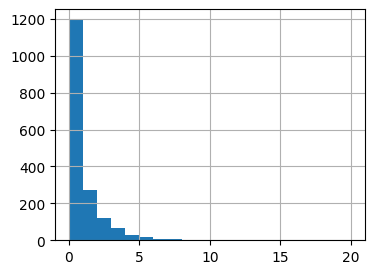

In [61]:
n_admissions_before_target_cancer = df[df["subject_id"].isin(target_cancer_patients["subject_id"])].groupby("subject_id").apply(partial(n_admissions_before_event, target=TARGET_CANCER))
n_admissions_before_target_cancer.hist(bins=range(21), figsize=(4, 3))

In [62]:
target_cancer_patients_with_history = list(n_admissions_before_target_cancer[n_admissions_before_target_cancer >= 1].index)
len(target_cancer_patients_with_history)

545

/tmp/ipykernel_436255/2225045955.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  timedelta_to_target_cancer = df[df["subject_id"].isin(target_cancer_patients_with_history)].groupby("subject_id").apply(partial(timedelta_to_event_from_prev_record, target=TARGET_CANCER))


<Axes: >

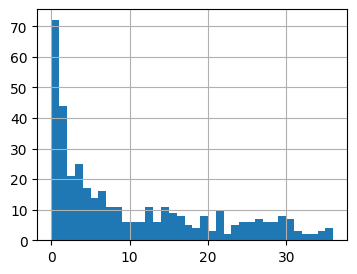

In [63]:
timedelta_to_target_cancer = df[df["subject_id"].isin(target_cancer_patients_with_history)].groupby("subject_id").apply(partial(timedelta_to_event_from_prev_record, target=TARGET_CANCER))
timedelta_to_target_cancer = timedelta_to_target_cancer/30
timedelta_to_target_cancer.hist(bins=range(37), figsize=(4, 3))

In [64]:
timedelta_to_target_cancer.head()

subject_id
10014610      3.600000
10024331      4.533333
10027221     21.133333
10038849      3.900000
10046298    129.700000
dtype: float64

In [67]:
timedelta_to_target_cancer = pd.DataFrame({
    "subject_id": list(timedelta_to_target_cancer.index),
    "timedelta_to_index": list(timedelta_to_target_cancer.values), 
})

In [68]:
timedelta_to_target_cancer.head()

,subject_id,timedelta_to_index
0,10014610,3.600000
1,10024331,4.533333
2,10027221,21.133333
3,10038849,3.900000
4,10046298,129.700000


In [69]:
target_cancer_patients = pd.merge(
    how="right",
    left=cancer_patients,
    right=timedelta_to_target_cancer,
    on="subject_id",
)

In [70]:
target_cancer_patients.head()

,subject_id,icd10_category,admittime,birth_year,gender,timedelta_to_index
0,10014610,C61,2174-04-23 13:15:00,2100-01-01,M,3.600000
1,10024331,C61,2140-05-23 02:40:00,2068-01-01,M,4.533333
2,10027221,C61,2164-02-08 00:00:00,2093-01-01,M,21.133333
3,10038849,C61,2189-08-27 15:25:00,2109-01-01,M,3.900000
4,10046298,C61,2195-12-02 09:23:00,2139-01-01,M,129.700000


In [92]:
target_cancer_patients.count()

subject_id            545
icd10_category        545
admittime             545
birth_year            545
gender                545
timedelta_to_index    545
dtype: int64

In [71]:
target_cancer_patients.to_csv(f"{TARGET_CANCER}_patients.csv", index=False)

### Healthy controls

In [74]:
healthy_patients = df[~df['subject_id'].isin(cancer_patients.index)][['subject_id', 'admittime', "birth_year", "gender"]].groupby(['subject_id']).last().reset_index()

In [75]:
healthy_patients.head()

,subject_id,admittime,birth_year,gender
0,10000032,2180-08-05 23:44:00,2128-01-01,F
1,10000068,2160-03-03 23:16:00,2141-01-01,F
2,10000084,2160-12-28 05:11:00,2088-01-01,M
3,10000108,2163-09-27 23:17:00,2138-01-01,M
4,10000117,2183-09-18 18:10:00,2126-01-01,F


In [76]:
healthy_patients.shape

(223291, 4)

/tmp/ipykernel_436255/244387413.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_admissions = df[df["subject_id"].isin(healthy_patients["subject_id"])].groupby("subject_id").apply(lambda x: x["hadm_id"].nunique())


<Axes: >

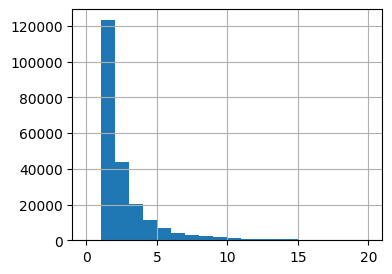

In [79]:
n_admissions = df[df["subject_id"].isin(healthy_patients["subject_id"])].groupby("subject_id").apply(lambda x: x["hadm_id"].nunique())
n_admissions.hist(bins=range(21), figsize=(4, 3))

In [81]:
healthy_patients_with_history = list(n_admissions[n_admissions > 1].index)
len(healthy_patients_with_history)

100057

/tmp/ipykernel_436255/1699065766.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hp_last_timedelta = df[df["subject_id"].isin(healthy_patients_with_history)].groupby("subject_id").apply(last_timedelta)


<Axes: >

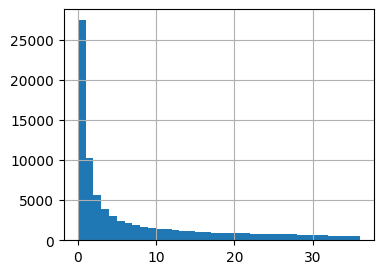

In [84]:
hp_last_timedelta = df[df["subject_id"].isin(healthy_patients_with_history)].groupby("subject_id").apply(last_timedelta)
hp_last_timedelta = hp_last_timedelta/30
hp_last_timedelta.hist(bins=range(37), figsize=(4, 3))

In [85]:
hp_last_timedelta.head()

subject_id
10000032     0.433333
10000084     1.233333
10000117    22.400000
10000635    91.433333
10000690    15.066667
dtype: float64

In [86]:
hp_last_timedelta = pd.DataFrame({
    "subject_id": list(hp_last_timedelta.index),
    "timedelta_to_index": list(hp_last_timedelta.values), 
})

In [87]:
hp_last_timedelta.head()

,subject_id,timedelta_to_index
0,10000032,0.433333
1,10000084,1.233333
2,10000117,22.400000
3,10000635,91.433333
4,10000690,15.066667


In [89]:
healthy_patients_with_history = pd.merge(
    how="right",
    left=healthy_patients,
    right=hp_last_timedelta,
    on="subject_id",
)

In [90]:
healthy_patients_with_history.head()

,subject_id,admittime,birth_year,gender,timedelta_to_index
0,10000032,2180-08-05 23:44:00,2128-01-01,F,0.433333
1,10000084,2160-12-28 05:11:00,2088-01-01,M,1.233333
2,10000117,2183-09-18 18:10:00,2126-01-01,F,22.400000
3,10000635,2143-12-23 14:55:00,2062-01-01,F,91.433333
4,10000690,2152-01-28 23:40:00,2064-01-01,F,15.066667


In [91]:
healthy_patients_with_history.count()

subject_id            100057
admittime             100057
birth_year            100057
gender                100057
timedelta_to_index    100057
dtype: int64

In [93]:
healthy_patients_with_history.to_csv("healthy_patients_with_history.csv", index=False)

### Some auxiliary columns

In [95]:
target_cancer_patients["age"] = target_cancer_patients.apply(lambda x: (x["admittime"] - x["birth_year"]).days/365.25, axis=1)
healthy_patients_with_history["age"] = healthy_patients_with_history.apply(lambda x: (x["admittime"] - x["birth_year"]).days/365.25, axis=1)

In [105]:
target_cancer_patients = pd.merge(
    how="left",
    left=target_cancer_patients,
    right=n_admissions_before_target_cancer.reset_index().rename({0: "n_admissions"}, axis=1),
    on="subject_id"
)
print(target_cancer_patients.count())

healthy_patients_with_history = pd.merge(
    how="left",
    left=healthy_patients_with_history,
    right=n_admissions.reset_index().rename({0: "n_admissions"}, axis=1),
    on="subject_id"
)
print(healthy_patients_with_history.count())

subject_id            545
icd10_category        545
admittime             545
birth_year            545
gender                545
timedelta_to_index    545
age                   545
n_admissions          545
dtype: int64
subject_id            100057
admittime             100057
birth_year            100057
gender                100057
timedelta_to_index    100057
age                   100057
n_admissions          100057
dtype: int64


In [106]:
target_cancer_patients.to_csv(f"{TARGET_CANCER}_patients.csv", index=False)
healthy_patients_with_history.to_csv("healthy_patients_with_history.csv", index=False)

In [ ]:
AGE_STEP = 5 # years
target_cancer_patients["age_bin"] = target_cancer_patients["age"].apply(lambda x: int(x / AGE_STEP))
healthy_patients_with_history["age_bin"] = healthy_patients_with_history["age"].apply(lambda x: int(x / AGE_STEP))

In [111]:
TIMEDELTA_STEP = 1 # months
target_cancer_patients["timedelta_bin"] = target_cancer_patients["timedelta_to_index"].apply(lambda x: int(x / TIMEDELTA_STEP))
healthy_patients_with_history["timedelta_bin"] = healthy_patients_with_history["timedelta_to_index"].apply(lambda x: int(x / TIMEDELTA_STEP))

### Matching

In [165]:
target_cancer_patients.shape

(545, 10)

In [ ]:
target_cancer_patients_horizoned = target_cancer_patients[target_cancer_patients["timedelta_to_index"] < PREDICTION_HORIZON]
target_cancer_patients_horizoned.shape

(391, 10)

In [168]:
RANDOM_STATE = 42
matched_cancer_patients = pd.DataFrame()
matched_healthy_patients = pd.DataFrame()

for gender in tqdm(sorted(target_cancer_patients_horizoned["gender"].unique())):
    for age_bin in tqdm(sorted(target_cancer_patients_horizoned["age_bin"].unique())):
        for timedelta_bin in sorted(target_cancer_patients_horizoned["timedelta_bin"].unique()):
            bin_cancer_patients = target_cancer_patients_horizoned[
                (target_cancer_patients_horizoned["gender"] == gender) & \
                (target_cancer_patients_horizoned["age_bin"] == age_bin) & \
                (target_cancer_patients_horizoned["timedelta_bin"] == timedelta_bin)
            ]
            n_cancer_patients = len(bin_cancer_patients)
            if n_cancer_patients == 0:
                continue
            bin_healthy_patients = healthy_patients_with_history[
                (healthy_patients_with_history["gender"] == gender) & \
                (healthy_patients_with_history["age_bin"] == age_bin) & \
                (healthy_patients_with_history["timedelta_bin"] == timedelta_bin)
            ]
            n_healthy_patients = len(bin_healthy_patients)
            print("gender:", gender, "age:", age_bin*AGE_STEP, "timedelta:", timedelta_bin*TIMEDELTA_STEP, "n_cancer", n_cancer_patients, "n_healthy", n_healthy_patients)
            if n_healthy_patients < n_cancer_patients:
                bin_cancer_patients = bin_cancer_patients.sample(n=n_healthy_patients, random_state=RANDOM_STATE) #TODO: to match by history length
            elif n_healthy_patients > n_cancer_patients:
                bin_healthy_patients = bin_healthy_patients.sample(n=n_cancer_patients, random_state=RANDOM_STATE)

            matched_cancer_patients = pd.concat([matched_cancer_patients, bin_cancer_patients])
            matched_healthy_patients = pd.concat([matched_healthy_patients, bin_healthy_patients])

  0%|          | 0/1 [00:00<?, ?it/s]

gender: M age: 45 timedelta: 7 n_cancer 2 n_healthy 49
gender: M age: 45 timedelta: 8 n_cancer 1 n_healthy 41
gender: M age: 50 timedelta: 0 n_cancer 1 n_healthy 996
gender: M age: 50 timedelta: 1 n_cancer 2 n_healthy 374
gender: M age: 50 timedelta: 6 n_cancer 2 n_healthy 91
gender: M age: 50 timedelta: 8 n_cancer 1 n_healthy 60
gender: M age: 50 timedelta: 9 n_cancer 1 n_healthy 62
gender: M age: 50 timedelta: 10 n_cancer 1 n_healthy 42
gender: M age: 50 timedelta: 11 n_cancer 1 n_healthy 49
gender: M age: 50 timedelta: 14 n_cancer 1 n_healthy 43
gender: M age: 50 timedelta: 16 n_cancer 1 n_healthy 23
gender: M age: 50 timedelta: 17 n_cancer 1 n_healthy 33
gender: M age: 50 timedelta: 23 n_cancer 1 n_healthy 20
gender: M age: 50 timedelta: 28 n_cancer 2 n_healthy 22
gender: M age: 55 timedelta: 0 n_cancer 3 n_healthy 1221


gender: M age: 55 timedelta: 1 n_cancer 1 n_healthy 484
gender: M age: 55 timedelta: 2 n_cancer 1 n_healthy 282
gender: M age: 55 timedelta: 7 n_cancer 1 n_healthy 99
gender: M age: 55 timedelta: 8 n_cancer 1 n_healthy 84
gender: M age: 55 timedelta: 13 n_cancer 2 n_healthy 56
gender: M age: 55 timedelta: 15 n_cancer 1 n_healthy 49
gender: M age: 55 timedelta: 17 n_cancer 1 n_healthy 32
gender: M age: 55 timedelta: 18 n_cancer 1 n_healthy 38
gender: M age: 55 timedelta: 23 n_cancer 1 n_healthy 26
gender: M age: 55 timedelta: 24 n_cancer 1 n_healthy 27
gender: M age: 55 timedelta: 28 n_cancer 1 n_healthy 31
gender: M age: 55 timedelta: 33 n_cancer 2 n_healthy 23
gender: M age: 60 timedelta: 0 n_cancer 3 n_healthy 1372
gender: M age: 60 timedelta: 1 n_cancer 4 n_healthy 578
gender: M age: 60 timedelta: 2 n_cancer 2 n_healthy 318
gender: M age: 60 timedelta: 3 n_cancer 6 n_healthy 203
gender: M age: 60 timedelta: 4 n_cancer 2 n_healthy 183


gender: M age: 60 timedelta: 5 n_cancer 1 n_healthy 155
gender: M age: 60 timedelta: 6 n_cancer 1 n_healthy 120
gender: M age: 60 timedelta: 7 n_cancer 1 n_healthy 102
gender: M age: 60 timedelta: 8 n_cancer 2 n_healthy 102
gender: M age: 60 timedelta: 11 n_cancer 3 n_healthy 84
gender: M age: 60 timedelta: 12 n_cancer 2 n_healthy 71
gender: M age: 60 timedelta: 14 n_cancer 2 n_healthy 55
gender: M age: 60 timedelta: 19 n_cancer 1 n_healthy 43
gender: M age: 60 timedelta: 20 n_cancer 1 n_healthy 37
gender: M age: 60 timedelta: 21 n_cancer 1 n_healthy 34
gender: M age: 60 timedelta: 22 n_cancer 1 n_healthy 31
gender: M age: 60 timedelta: 24 n_cancer 2 n_healthy 39
gender: M age: 60 timedelta: 25 n_cancer 1 n_healthy 32
gender: M age: 60 timedelta: 26 n_cancer 1 n_healthy 29
gender: M age: 60 timedelta: 27 n_cancer 1 n_healthy 33
gender: M age: 60 timedelta: 29 n_cancer 1 n_healthy 23
gender: M age: 60 timedelta: 35 n_cancer 2 n_healthy 37
gender: M age: 65 timedelta: 0 n_cancer 10 n_hea

gender: M age: 65 timedelta: 32 n_cancer 1 n_healthy 32
gender: M age: 65 timedelta: 34 n_cancer 1 n_healthy 26
gender: M age: 70 timedelta: 0 n_cancer 12 n_healthy 1310
gender: M age: 70 timedelta: 1 n_cancer 2 n_healthy 579
gender: M age: 70 timedelta: 2 n_cancer 2 n_healthy 323
gender: M age: 70 timedelta: 3 n_cancer 7 n_healthy 200
gender: M age: 70 timedelta: 4 n_cancer 4 n_healthy 160
gender: M age: 70 timedelta: 5 n_cancer 1 n_healthy 118
gender: M age: 70 timedelta: 6 n_cancer 1 n_healthy 107
gender: M age: 70 timedelta: 7 n_cancer 1 n_healthy 71
gender: M age: 70 timedelta: 8 n_cancer 2 n_healthy 101
gender: M age: 70 timedelta: 9 n_cancer 1 n_healthy 80
gender: M age: 70 timedelta: 10 n_cancer 1 n_healthy 53
gender: M age: 70 timedelta: 13 n_cancer 2 n_healthy 68
gender: M age: 70 timedelta: 15 n_cancer 2 n_healthy 57
gender: M age: 70 timedelta: 16 n_cancer 1 n_healthy 46
gender: M age: 70 timedelta: 19 n_cancer 1 n_healthy 41
gender: M age: 70 timedelta: 20 n_cancer 1 n_hea

...

gender: M age: 80 timedelta: 6 n_cancer 2 n_healthy 82
gender: M age: 80 timedelta: 7 n_cancer 3 n_healthy 82
gender: M age: 80 timedelta: 8 n_cancer 1 n_healthy 66
gender: M age: 80 timedelta: 9 n_cancer 1 n_healthy 49
gender: M age: 80 timedelta: 10 n_cancer 1 n_healthy 53
gender: M age: 80 timedelta: 11 n_cancer 1 n_healthy 56
gender: M age: 80 timedelta: 12 n_cancer 1 n_healthy 29
gender: M age: 80 timedelta: 14 n_cancer 2 n_healthy 29
gender: M age: 80 timedelta: 15 n_cancer 1 n_healthy 33
gender: M age: 80 timedelta: 16 n_cancer 1 n_healthy 41
gender: M age: 80 timedelta: 17 n_cancer 1 n_healthy 33
gender: M age: 80 timedelta: 19 n_cancer 2 n_healthy 29
gender: M age: 80 timedelta: 20 n_cancer 1 n_healthy 30
gender: M age: 80 timedelta: 21 n_cancer 2 n_healthy 34
gender: M age: 80 timedelta: 25 n_cancer 1 n_healthy 21
gender: M age: 80 timedelta: 28 n_cancer 1 n_healthy 14
gender: M age: 80 timedelta: 29 n_cancer 1 n_healthy 21
gender: M age: 80 timedelta: 35 n_cancer 1 n_healthy

gender: M age: 85 timedelta: 1 n_cancer 4 n_healthy 371
gender: M age: 85 timedelta: 2 n_cancer 5 n_healthy 178
gender: M age: 85 timedelta: 4 n_cancer 1 n_healthy 92
gender: M age: 85 timedelta: 5 n_cancer 3 n_healthy 77
gender: M age: 85 timedelta: 6 n_cancer 2 n_healthy 58
gender: M age: 85 timedelta: 8 n_cancer 1 n_healthy 53
gender: M age: 85 timedelta: 9 n_cancer 1 n_healthy 46
gender: M age: 85 timedelta: 13 n_cancer 1 n_healthy 25
gender: M age: 85 timedelta: 15 n_cancer 3 n_healthy 30
gender: M age: 85 timedelta: 16 n_cancer 1 n_healthy 24
gender: M age: 85 timedelta: 17 n_cancer 1 n_healthy 17
gender: M age: 85 timedelta: 18 n_cancer 2 n_healthy 21
gender: M age: 85 timedelta: 23 n_cancer 1 n_healthy 27
gender: M age: 85 timedelta: 24 n_cancer 1 n_healthy 20
gender: M age: 85 timedelta: 25 n_cancer 1 n_healthy 22
gender: M age: 85 timedelta: 29 n_cancer 2 n_healthy 21
gender: M age: 85 timedelta: 30 n_cancer 1 n_healthy 23
gender: M age: 85 timedelta: 32 n_cancer 1 n_healthy 

gender: M age: 90 timedelta: 0 n_cancer 10 n_healthy 464
gender: M age: 90 timedelta: 1 n_cancer 5 n_healthy 221
gender: M age: 90 timedelta: 2 n_cancer 3 n_healthy 104
gender: M age: 90 timedelta: 3 n_cancer 2 n_healthy 75
gender: M age: 90 timedelta: 4 n_cancer 2 n_healthy 65
gender: M age: 90 timedelta: 5 n_cancer 2 n_healthy 54
gender: M age: 90 timedelta: 6 n_cancer 1 n_healthy 44
gender: M age: 90 timedelta: 7 n_cancer 3 n_healthy 48
gender: M age: 90 timedelta: 8 n_cancer 1 n_healthy 29
gender: M age: 90 timedelta: 10 n_cancer 1 n_healthy 28
gender: M age: 90 timedelta: 11 n_cancer 1 n_healthy 26
gender: M age: 90 timedelta: 12 n_cancer 3 n_healthy 21
gender: M age: 90 timedelta: 14 n_cancer 2 n_healthy 20
gender: M age: 90 timedelta: 15 n_cancer 1 n_healthy 20
gender: M age: 90 timedelta: 24 n_cancer 1 n_healthy 12
gender: M age: 90 timedelta: 30 n_cancer 2 n_healthy 14
gender: M age: 90 timedelta: 31 n_cancer 1 n_healthy 9
gender: M age: 95 timedelta: 1 n_cancer 1 n_healthy 26

100%|██████████| 1/1 [00:02<00:00,  2.24s/it]

gender: M age: 95 timedelta: 25 n_cancer 1 n_healthy 4
gender: M age: 95 timedelta: 34 n_cancer 1 n_healthy 3


In [169]:
matched_cancer_patients.shape, matched_healthy_patients.shape

((391, 10), (391, 9))

In [170]:
matched_patients = pd.concat([
    matched_cancer_patients,
    matched_healthy_patients
], axis=0)
matched_patients.shape

(782, 10)

In [171]:
matched_patients.sample(5)

,subject_id,icd10_category,admittime,birth_year,gender,timedelta_to_index,age,n_admissions,age_bin,timedelta_bin
80078,18001157,NaN,2113-03-12 21:24:00,2032-01-01,M,8.700000,81.190965,2,16,8
160,12944869,C61,2195-07-10 11:00:00,2124-01-01,M,2.233333,71.520876,3,14,2
62919,16301503,NaN,2153-06-28 21:09:00,2077-01-01,M,0.633333,76.484600,3,15,0
42942,14310086,NaN,2187-08-13 13:05:00,2119-01-01,M,5.400000,68.613279,12,13,5
53,11011076,C61,2178-12-02 21:43:00,2096-01-01,M,2.133333,82.915811,1,16,2


In [ ]:
# matched_patients.to_csv(f"{TARGET_CANCER}_matched_patients.csv", index=False)

In [173]:
#healthy
matched_patients[matched_patients["icd10_category"].isna()].n_admissions.mean(), matched_patients[matched_patients["icd10_category"].isna()].n_admissions.std()

(np.float64(4.746803069053708), np.float64(4.270331009759505))

In [174]:
#cancer
matched_patients[matched_patients["icd10_category"].notna()].n_admissions.mean(), matched_patients[matched_patients["icd10_category"].notna()].n_admissions.std()

(np.float64(2.9002557544757033), np.float64(4.6335205573014075))

# Features generation

In [9]:
matched_patients = pd.read_csv(f"{TARGET_CANCER}_matched_patients.csv").set_index("subject_id", drop=True)
matched_cancer_patients = matched_patients[matched_patients["icd10_category"].notna()]
matched_healthy_patients = matched_patients[matched_patients["icd10_category"].isna()]
matched_cancer_patients.shape, matched_healthy_patients.shape

((391, 9), (391, 9))

## Let's load embeddings

In [17]:
import torch
model = "deepseek-ai_DeepSeek-V3"
aggregation = "max"
with open(f"embeddings/{model}_{aggregation}.pkl", "rb") as f:
    embeddings = pickle.load(f)

/home/d.kornilov/work/Revealing-interconnections-between-diseases/.venv/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  retu

In [18]:
embeddings.keys()

dict_keys(['Qwen/Qwen3-235B-A22B-Instruct-2507', 'yandex/YandexGPT-5-Lite-8B-instruct', 'deepseek-ai/DeepSeek-V3'])

In [19]:
for model in embeddings:
    embeddings[model] = {k: v.float().numpy() for k, v in embeddings[model].items()}

In [20]:
embeddings['deepseek-ai/DeepSeek-V3']['A01']

array([0.06787109, 0.07177734, 0.05029297, ..., 0.08203125, 0.08642578,
       0.00289917], dtype=float32)

## Dataset generation

In [22]:
def get_features_from_history(patient_df, embeddings, agg=np.nanmean):
    embeddings_sequence = np.stack([x for x in patient_df["icd10_category"].apply(lambda x: embeddings[x] if x in embeddings else None).values if x is not None])
    return agg(
        embeddings_sequence, 
        axis=0
    )

#for parallel computing
def build_patient_sample(args):
    is_cancer, p, r, model = args
    date_index = r['admittime'] #time of last admission or time of cancer diagnosis
    patient_df = df[df["subject_id"] == p]

    if is_cancer:
        patient_df_prev = get_history_before_event(patient_df, target=TARGET_CANCER)
    else:
        patient_df_prev = patient_df[patient_df["admittime"] != date_index]
        
    row = get_features_from_history(patient_df_prev, embeddings[model])
    row = {f"feature_{i}": v for i, v in enumerate(row)}
    row["Y"] = int(is_cancer)
    row["subject_id"] = p

    return row

In [34]:
#for parallel computing
# model = "deepseek-ai/DeepSeek-V3"
model = "Qwen/Qwen3-235B-A22B-Instruct-2507"
# model = "yandex/YandexGPT-5-Lite-8B-instruct"
cancer_args = [(True, p, r, model) for p, r in matched_cancer_patients.iterrows()]
health_args = [(False, p, r, model) for p, r in matched_healthy_patients.iterrows()]
all_args = health_args + cancer_args

X = []
# with Pool(processes=min(N_CORES_TO_USE, cpu_count())) as pool:
#     pbar = tqdm(
#         pool.imap_unordered(build_patient_sample, all_args), 
#         total=len(all_args)
#     )
#     for patient_row in pbar:
#         pbar.set_description(str(patient_row["subject_id"]))
#         X.append(patient_row)

for args in tqdm(all_args):
    patient_row = build_patient_sample(args)
    X.append(patient_row)

X = pd.DataFrame(X)

100%|██████████| 782/782 [00:08<00:00, 90.71it/s] 


In [35]:
X.shape

(782, 4098)

In [36]:
X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_4088,feature_4089,feature_4090,feature_4091,feature_4092,feature_4093,feature_4094,feature_4095,Y,subject_id
0,0.009171,0.016747,0.018661,0.044739,0.014893,0.021652,0.032227,0.028442,0.030304,0.008797,...,0.028557,0.017380,0.019379,0.029480,0.013840,0.016235,0.020309,0.018524,0,12451740
1,0.020422,0.018509,0.015845,0.017090,0.026184,0.026270,0.016077,0.021362,0.019269,0.015465,...,0.021143,0.019492,0.016644,0.031470,0.019275,0.022241,0.020398,0.017517,0,18738693
2,0.015396,0.019665,0.020508,0.024243,0.025344,0.026045,0.022295,0.027698,0.024634,0.012403,...,0.022101,0.017689,0.017870,0.025806,0.014034,0.014883,0.014165,0.013116,0,15554479
3,0.027344,0.012543,0.017670,0.029480,0.030640,0.018555,0.010910,0.007286,0.017548,0.025574,...,0.009201,0.018677,0.015442,0.016983,0.011475,0.020264,0.007904,0.013092,0,18556743
4,0.017401,0.024060,0.019894,0.026407,0.021431,0.027052,0.024329,0.024037,0.025033,0.017370,...,0.020235,0.015941,0.018354,0.024698,0.016310,0.014269,0.016408,0.018343,0,18650767


In [37]:
X.to_csv(f"{TARGET_CANCER}_{model.replace('/', '_')}_features_max.csv", index=False)